# start_here: pySTAMPS API, backend modes, and speed evidence

This is the canonical first notebook for pySTAMPS.

Read it when you want to understand:

1. The pySTAMPS API: CLI commands, Python objects, and kernel calls.
2. How to switch compute modality: Python baseline, native Rust extension, and CUDA where available.
3. What speedups the accelerated paths bring, with parity checks beside every timing.

The key rule is: **backend mode changes how numerical kernels run; it does not change the StaMPS workflow contract.** Python is the reference path, and accelerated results matter only when parity passes.


## How to read this notebook

Run cells top to bottom. The first half teaches the API and backend switch. The second half runs deterministic benchmarks and plots the result.

If you only read one table, read **Rust speed evidence by kernel**. It shows the measured Rust/native speedup and parity result for every Rust-relevant kernel.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import json
import os
import statistics
import tempfile
import time
from datetime import UTC, datetime
from pathlib import Path
from typing import Any, Callable

os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from pystamps.config import RunConfig, RuntimeConfig, load_config
from pystamps.io.mat import read_mat
from pystamps.pipeline.stages import run_pipeline
from pystamps.pipeline.types import PipelineContext
from pystamps.kernels import (
    BackendUnavailableError,
    describe_backend_matrix,
    run_stage2_grid_accumulate_kernel,
    run_stage2_histogram_kernel,
    run_stage2_topofit_coh_row_invariant_kernel,
    run_stage2_topofit_kernel,
    run_stage2_topofit_row_invariant_kernel,
    run_stage4_edge_stats_kernel,
    run_stage7_scla_kernel,
    run_stage8_edge_noise_kernel,
)


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'pystamps').exists():
            return candidate
    raise RuntimeError('Could not locate repo root from this notebook')


REPO_ROOT = find_repo_root()
AUDIT_JSON = REPO_ROOT / 'inputs_and_outputs' / 'validation_runs' / 'latest_small_baseline_audit.json'
GOLDEN_ROOT = REPO_ROOT / 'inputs_and_outputs' / 'InSAR_dataset_test_stage8diag'
GOLDEN_PATCH = 'PATCH_1'
MANIFEST_JSON = REPO_ROOT / 'pystamps' / 'data' / 'audited_workflow_manifest.json'
EVIDENCE_NOTEBOOK = REPO_ROOT / 'notebooks' / '04_rust_end2end_parity_validation.ipynb'

native_import_error = None
native_spec = importlib.util.find_spec('pystamps.kernels._stage2_native')
try:
    native_mod = importlib.import_module('pystamps.kernels._stage2_native') if native_spec else None
except Exception as exc:
    native_mod = None
    native_import_error = f'{type(exc).__name__}: {exc}'

native_path = Path(native_spec.origin) if native_spec and native_spec.origin and native_mod is not None else None


def relpath(path: str | Path | None) -> str:
    if path is None:
        return '<missing>'
    candidate = Path(path)
    try:
        return str(candidate.resolve().relative_to(REPO_ROOT))
    except Exception:
        return str(candidate)


def modified_utc(path: Path | None) -> str:
    if path is None or not path.exists():
        return '<missing>'
    return datetime.fromtimestamp(path.stat().st_mtime, UTC).isoformat(timespec='seconds')


context_df = pd.DataFrame([
    {'item': 'repo root', 'value': relpath(REPO_ROOT)},
    {'item': 'single-master golden dataset', 'value': relpath(GOLDEN_ROOT)},
        {'item': 'focused StaMPS audit artifact', 'value': relpath(AUDIT_JSON)},
    {'item': 'full audit manifest', 'value': relpath(MANIFEST_JSON)},
    {'item': 'compiled Rust/native module', 'value': relpath(native_path) if native_path else '<not importable>'},
    {'item': 'native module modified UTC', 'value': modified_utc(native_path)},
    {'item': 'native import error', 'value': native_import_error or '<none>'},
])
display(context_df)


,item,value
0,repo root,.
1,single-master golden dataset,inputs_and_outputs/InSAR_dataset_test_stage8diag
2,focused StaMPS audit artifact,inputs_and_outputs/validation_runs/latest_smal...
3,full audit manifest,pystamps/data/audited_workflow_manifest.json
4,compiled Rust/native module,pystamps/kernels/_stage2_native.cpython-314-x8...
5,native module modified UTC,2026-04-28T07:40:10+00:00
6,native import error,<none>


## 1. pySTAMPS API in one screen

Most users need three layers:

- **CLI API** for workflow runs and verification.
- **Config API** for repeatable backend choices.
- **Kernel API** for direct experiments and focused performance checks.


In [2]:
api_rows = [
    {'task': 'Run a workflow', 'surface': 'CLI', 'example': 'uv run pystamps run --dataset <dataset> --start-step 1 --end-step 8'},
    {'task': 'Verify against golden data', 'surface': 'CLI', 'example': 'uv run pystamps verify --dataset <dataset> --reference-root <golden>'},
    {'task': 'Inspect backend coverage', 'surface': 'CLI/Python', 'example': 'uv run pystamps describe-backends / describe_backend_matrix()'},
    {'task': 'Load config', 'surface': 'Python config API', 'example': 'cfg = load_config("examples/config.yaml")'},
    {'task': 'Call a kernel directly', 'surface': 'Python kernel API', 'example': 'run_stage8_edge_noise_kernel(uw_ph, node_a, node_b, backend="native")'},
]
display(pd.DataFrame(api_rows))


,task,surface,example
0,Run a workflow,CLI,uv run pystamps run --dataset <dataset> --star...
1,Verify against golden data,CLI,uv run pystamps verify --dataset <dataset> --r...
2,Inspect backend coverage,CLI/Python,uv run pystamps describe-backends / describe_b...
3,Load config,Python config API,"cfg = load_config(""examples/config.yaml"")"
4,Call a kernel directly,Python kernel API,"run_stage8_edge_noise_kernel(uw_ph, node_a, no..."


## 2. Switching modality without changing the workflow

`runtime.backend` controls workflow orchestration. Kernel backend fields control numerical kernel modality.

Use config files for real runs. Use per-call `backend="python"`, `backend="native"`, or `backend="cuda"` when experimenting with a kernel directly.


In [3]:
config_examples = pd.DataFrame([
    {
        'goal': 'Safe default',
        'config': "runtime:\n  backend: auto\n  stage2_kernel_backend: auto",
        'effect': 'choose the best available registered path while preserving parity',
    },
    {
        'goal': 'Force Python reference kernels',
        'config': "runtime:\n  stage2_kernel_backend: python\n  kernel_backend_overrides:\n    stage4_edge_stats: python\n    stage7_scla: python\n    stage8_edge_noise: python",
        'effect': 'bypass accelerated kernels while debugging parity',
    },
    {
        'goal': 'Force Rust/native kernels',
        'config': "runtime:\n  stage2_kernel_backend: native\n  kernel_backend_overrides:\n    stage4_edge_stats: native\n    stage7_scla: native\n    stage8_edge_noise: native",
        'effect': 'use the compiled native path wherever the public API exposes one',
    },
    {
        'goal': 'Use CUDA where supported',
        'config': "runtime:\n  kernel_backend_overrides:\n    stage7_scla: cuda\n    stage8_edge_noise: cuda",
        'effect': 'request CUDA for Stage 7 and Stage 8 kernels',
    },
])
display(config_examples)

with tempfile.NamedTemporaryFile('w', suffix='.yaml') as handle:
    handle.write("runtime:\n  stage2_kernel_backend: native\n  kernel_backend_overrides:\n    stage8_edge_noise: native\n")
    handle.flush()
    loaded = load_config(handle.name)

display(pd.DataFrame([
    {'field': 'runtime.stage2_kernel_backend', 'value': loaded.runtime.stage2_kernel_backend},
    {'field': 'runtime.kernel_backend_overrides', 'value': loaded.runtime.kernel_backend_overrides},
]))


,goal,config,effect
0,Safe default,runtime:\n backend: auto\n stage2_kernel_bac...,choose the best available registered path whil...
1,Force Python reference kernels,runtime:\n stage2_kernel_backend: python\n k...,bypass accelerated kernels while debugging parity
2,Force Rust/native kernels,runtime:\n stage2_kernel_backend: native\n k...,use the compiled native path wherever the publ...
3,Use CUDA where supported,runtime:\n kernel_backend_overrides:\n sta...,request CUDA for Stage 7 and Stage 8 kernels


,field,value
0,runtime.stage2_kernel_backend,native
1,runtime.kernel_backend_overrides,{'stage8_edge_noise': 'native'}


## 3. Backend matrix in this environment

This table is generated from `describe_backend_matrix()`. It is the source of truth for registered kernels and available modalities.

`rust_speed_claim = yes` means this notebook includes a measured Rust/native speed row for that kernel. For some Stage-2 topofit paths, the high-level API is parity-guarded, so the speed row is labeled `rust_export` rather than `native_api`.


In [4]:
backend_matrix = describe_backend_matrix()
providers_df = pd.DataFrame([
    {
        'provider': provider,
        'available': info.get('available'),
        'aliases': ', '.join(info.get('aliases', [])),
        'description': info.get('description'),
        'unavailable_reason': info.get('unavailable_reason') or '<none>',
    }
    for provider, info in sorted(backend_matrix.get('providers', {}).items())
])
display(providers_df)

TOPIFIT_EXPORT_KERNELS = {
    'stage2_topofit',
    'stage2_topofit_row_invariant',
    'stage2_topofit_coh_row_invariant',
}
RUST_SPEED_KERNELS = {
    'stage2_grid_accumulate',
    'stage2_histogram',
    'stage2_topofit',
    'stage2_topofit_row_invariant',
    'stage2_topofit_coh_row_invariant',
    'stage4_edge_stats',
    'stage7_scla',
    'stage8_edge_noise',
}


def stage_from_kernel(kernel: str) -> str:
    if kernel.startswith('stage2_'):
        return '2'
    if kernel.startswith('stage4_'):
        return '4'
    if kernel.startswith('stage7_'):
        return '7'
    if kernel.startswith('stage8_'):
        return '8'
    return '?'


backend_df = pd.DataFrame([
    {
        'stage': stage_from_kernel(kernel),
        'kernel': kernel,
        'python_reference': info.get('baseline_backend', 'python'),
        'available_modalities': ', '.join(info.get('available_backends', [])),
        'rust_speed_claim': 'yes' if kernel in RUST_SPEED_KERNELS else 'no',
        'speed_evidence_source': 'rust_export' if kernel in TOPIFIT_EXPORT_KERNELS else 'native_api',
        'reader_note': 'measured below against Python' if kernel in RUST_SPEED_KERNELS else 'not measured here',
    }
    for kernel, info in sorted(backend_matrix.get('kernels', {}).items())
])
display(backend_df)


,provider,available,aliases,description,unavailable_reason
0,cuda,True,gpu,CuPy CUDA backend,GPU backend requested but CuPy is not available
1,native,True,,Compiled native backend,Native stage-2 extension is unavailable
2,python,True,cpu,NumPy/Python baseline backend,<none>


,stage,kernel,python_reference,available_modalities,rust_speed_claim,speed_evidence_source,reader_note
0,2,stage2_grid_accumulate,python,"native, python",yes,native_api,measured below against Python
1,2,stage2_histogram,python,"native, python",yes,native_api,measured below against Python
2,2,stage2_topofit,python,"native, python",yes,rust_export,measured below against Python
3,2,stage2_topofit_coh_row_invariant,python,"native, python",yes,rust_export,measured below against Python
4,2,stage2_topofit_row_invariant,python,"native, python",yes,rust_export,measured below against Python
5,4,stage4_edge_stats,python,"native, python",yes,native_api,measured below against Python
6,7,stage7_scla,python,"cuda, native, python",yes,native_api,measured below against Python
7,8,stage8_edge_noise,python,"cuda, native, python",yes,native_api,measured below against Python


## 4. Stage map with backend meaning

StaMPS stages stay the same. Backend modality only changes selected numerical hot spots inside those stages.


In [5]:
stage_map = pd.DataFrame([
    {'stage': '1. Load inputs', 'workflow_goal': 'Read StaMPS-style files into pySTAMPS structures.', 'backend_role': 'Python orchestration; no registered accelerated kernel.'},
    {'stage': '2. Estimate gamma/coherence', 'workflow_goal': 'Estimate coherence-like stability and residual phase terms.', 'backend_role': 'Rust/native kernels cover grid accumulation, histogramming, and topofit exports.'},
    {'stage': '3. Select persistent scatterers', 'workflow_goal': 'Keep candidates that pass selection thresholds.', 'backend_role': 'Python orchestration over Stage-2 products.'},
    {'stage': '4. Weed adjacent/noisy candidates', 'workflow_goal': 'Use edge statistics to remove weak or redundant candidates.', 'backend_role': 'Rust/native stage4_edge_stats is measured below.'},
    {'stage': '5. Merge patch products', 'workflow_goal': 'Promote patch outputs into merged products.', 'backend_role': 'Python orchestration and file layout.'},
    {'stage': '6. Unwrap phase products', 'workflow_goal': 'Resolve phase ambiguity into unwrapped products.', 'backend_role': 'Python orchestration plus external unwrap tooling.'},
    {'stage': '7. Estimate SCLA and velocity', 'workflow_goal': 'Fit look-angle error and velocity terms.', 'backend_role': 'Native and CUDA modalities are measured below.'},
    {'stage': '8. Final space-time filtering', 'workflow_goal': 'Estimate residual edge noise and filtered phase.', 'backend_role': 'Native and CUDA modalities are measured below.'},
])
display(stage_map)


,stage,workflow_goal,backend_role
0,1. Load inputs,Read StaMPS-style files into pySTAMPS structures.,Python orchestration; no registered accelerate...
1,2. Estimate gamma/coherence,Estimate coherence-like stability and residual...,"Rust/native kernels cover grid accumulation, h..."
2,3. Select persistent scatterers,Keep candidates that pass selection thresholds.,Python orchestration over Stage-2 products.
3,4. Weed adjacent/noisy candidates,Use edge statistics to remove weak or redundan...,Rust/native stage4_edge_stats is measured below.
4,5. Merge patch products,Promote patch outputs into merged products.,Python orchestration and file layout.
5,6. Unwrap phase products,Resolve phase ambiguity into unwrapped products.,Python orchestration plus external unwrap tool...
6,7. Estimate SCLA and velocity,Fit look-angle error and velocity terms.,Native and CUDA modalities are measured below.
7,8. Final space-time filtering,Estimate residual edge noise and filtered phase.,Native and CUDA modalities are measured below.


## 5. Golden dataset: run the Rust API stage by stage

This section uses real files from the bundled STAMPS golden data. The full single-master golden root is large, so `start_here` avoids a multi-minute full regeneration by default. Instead it does three concrete things:

- shows the exact Python API to run pySTAMPS stages with Rust/native kernels on a golden run copy,
- executes Rust/native kernels on arrays loaded from the golden dataset,
- shows stage-by-stage comparison tables and plots so readers can see what is being checked.

For an exhaustive full-run gate use `make audit`. For the deep stage notebook use `02_pystamps_stage_execution.ipynb`.


In [6]:
rust_run_config = RunConfig(
    runtime=RuntimeConfig(
        backend='threads',
        stage2_kernel_backend='native',
        stage2_native_threads=8,
        kernel_backend_overrides={
            'stage4_edge_stats': 'native',
            'stage7_scla': 'native',
            'stage8_edge_noise': 'native',
        },
    )
)

api_example = """
from pathlib import Path
from pystamps.config import RunConfig, RuntimeConfig
from pystamps.pipeline.types import PipelineContext
from pystamps.pipeline.stages import run_pipeline

rust_run_config = RunConfig(
    runtime=RuntimeConfig(
        backend='threads',
        stage2_kernel_backend='native',
        stage2_native_threads=8,
        kernel_backend_overrides={
            'stage4_edge_stats': 'native',
            'stage7_scla': 'native',
            'stage8_edge_noise': 'native',
        },
    )
)

report = run_pipeline(PipelineContext(
    dataset_root=Path('<run-copy-of-golden-dataset>'),
    run_config=rust_run_config,
    start_step=2,
    end_step=2,
))
"""

display(Markdown('**Native/Rust stage API**\n```python\n' + api_example.strip() + '\n```'))

dry_report = run_pipeline(
    PipelineContext(
        dataset_root=GOLDEN_ROOT,
        run_config=rust_run_config,
        start_step=1,
        end_step=8,
        dry_run=True,
    )
)

display(pd.DataFrame([
    {
        'stage': item.stage_id,
        'scope': item.scope,
        'target': item.target,
        'status': item.status,
        'planned_output': item.details,
    }
    for item in dry_report.results
]))


**Native/Rust stage API**
```python
from pathlib import Path
from pystamps.config import RunConfig, RuntimeConfig
from pystamps.pipeline.types import PipelineContext
from pystamps.pipeline.stages import run_pipeline

rust_run_config = RunConfig(
    runtime=RuntimeConfig(
        backend='threads',
        stage2_kernel_backend='native',
        stage2_native_threads=8,
        kernel_backend_overrides={
            'stage4_edge_stats': 'native',
            'stage7_scla': 'native',
            'stage8_edge_noise': 'native',
        },
    )
)

report = run_pipeline(PipelineContext(
    dataset_root=Path('<run-copy-of-golden-dataset>'),
    run_config=rust_run_config,
    start_step=2,
    end_step=2,
))
```

,stage,scope,target,status,planned_output
0,1,patch,PATCH_1,skipped_existing,ps1.mat present
1,2,patch,PATCH_1,skipped_existing,pm1.mat present
2,3,patch,PATCH_1,skipped_existing,select1.mat present
3,4,patch,PATCH_1,skipped_existing,weed1.mat present
4,5,patch,PATCH_1,skipped_existing,ph2.mat present
5,5,merged,InSAR_dataset_test_stage8diag,skipped_existing,ifgstd2.mat present
6,6,merged,InSAR_dataset_test_stage8diag,skipped_existing,phuw2.mat present
7,7,merged,InSAR_dataset_test_stage8diag,skipped_existing,scla2.mat present
8,8,merged,InSAR_dataset_test_stage8diag,skipped_existing,uw_space_time.mat present


In [7]:
def finite_max_abs(left: Any, right: Any) -> float:
    left_arr = np.asarray(left)
    right_arr = np.asarray(right)
    if left_arr.shape != right_arr.shape:
        return float('inf')
    finite = np.isfinite(left_arr) & np.isfinite(right_arr)
    if not np.array_equal(left_arr[~finite], right_arr[~finite], equal_nan=True):
        return float('inf')
    return float(np.max(np.abs(left_arr[finite] - right_arr[finite]))) if np.any(finite) else 0.0


def time_call(fn: Callable[[], Any]) -> tuple[float, Any]:
    t0 = time.perf_counter()
    result = fn()
    return time.perf_counter() - t0, result


def compact_shape(value: Any) -> str:
    return 'x'.join(str(part) for part in np.asarray(value).shape)


def as_lonlat_points(value: Any, limit: int = 20000) -> np.ndarray:
    arr = np.asarray(value, dtype=float)
    if arr.ndim != 2:
        return np.empty((0, 2), dtype=float)
    if arr.shape[0] == 2 and arr.shape[1] != 2:
        arr = arr.T
    if arr.shape[1] > 2:
        arr = arr[:, :2]
    if arr.shape[0] > limit:
        arr = arr[np.linspace(0, arr.shape[0] - 1, limit, dtype=int)]
    return arr


golden_rows: list[dict[str, Any]] = []
golden_plot_payload: dict[str, Any] = {}
patch_root = GOLDEN_ROOT / GOLDEN_PATCH
ps1 = read_mat(patch_root / 'ps1.mat')
ph1 = read_mat(patch_root / 'ph1.mat')
pm1 = read_mat(patch_root / 'pm1.mat')
bp1 = read_mat(patch_root / 'bp1.mat')
select1 = read_mat(patch_root / 'select1.mat')
weed1 = read_mat(patch_root / 'weed1.mat')
ps2 = read_mat(GOLDEN_ROOT / 'ps2.mat')
phuw2 = read_mat(GOLDEN_ROOT / 'phuw2.mat')

# Stage 1: context data from the golden patch.
golden_rows.append({
    'stage': 1,
    'rust_api_exercised': 'no registered Rust kernel',
    'comparison': 'golden input anatomy',
    'data': f"{int(np.asarray(ps1['lonlat']).shape[0]):,} PS, {int(np.asarray(ps1['day']).size)} acquisitions",
    'status': 'context',
    'speedup_vs_python': np.nan,
    'max_abs': np.nan,
})
golden_plot_payload['stage1_lonlat'] = as_lonlat_points(ps1['lonlat'])

# Stage 2: run the public native grid kernel on golden ph_weight/grid data and compare to golden ph_grid.
grid_ij = np.asarray(pm1['grid_ij'], dtype=np.int64)
ph_grid_golden = np.asarray(pm1['ph_grid'])
grid_lin = (grid_ij[:, 0] - 1) * ph_grid_golden.shape[1] + (grid_ij[:, 1] - 1)
native_sec, ph_grid_native = time_call(lambda: run_stage2_grid_accumulate_kernel(pm1['ph_weight'], grid_lin, ph_grid_golden.shape[0], ph_grid_golden.shape[1], backend='native', threads=8))
golden_rows.append({
    'stage': 2,
    'rust_api_exercised': 'run_stage2_grid_accumulate_kernel(..., backend="native")',
    'comparison': 'native output vs STAMPS golden pm1.ph_grid',
    'data': f"ph_weight {compact_shape(pm1['ph_weight'])}, ph_grid {compact_shape(ph_grid_golden)}; speed measured below",
    'status': 'pass' if finite_max_abs(ph_grid_native, ph_grid_golden) <= 1e-6 else 'fail',
    'speedup_vs_python': np.nan,
    'max_abs': finite_max_abs(ph_grid_native, ph_grid_golden),
})
golden_plot_payload['stage2_diff'] = np.abs(ph_grid_native - ph_grid_golden).reshape(-1)

# Stage 3: context data from selection artifacts.
keep = np.asarray(select1['keep_ix']).reshape(-1).astype(bool)
golden_rows.append({
    'stage': 3,
    'rust_api_exercised': 'no registered Rust kernel',
    'comparison': 'golden selection artifact anatomy',
    'data': f"{int(keep.sum()):,} kept / {keep.size:,} selected candidates",
    'status': 'context',
    'speedup_vs_python': np.nan,
    'max_abs': np.nan,
})
golden_plot_payload['stage3_counts'] = {'kept': int(keep.sum()), 'rejected': int(keep.size - keep.sum())}

# Stage 4: run native edge stats on a compact golden-derived phase/edge sample and compare to Python.
n_stage4_node = min(6000, np.asarray(ph1['ph']).shape[0])
n_stage4_ifg = min(20, np.asarray(ph1['ph']).shape[1])
ph_weed_sample = np.asarray(ph1['ph'][:n_stage4_node, :n_stage4_ifg], dtype=np.complex128)
node_a4 = np.arange(n_stage4_node - 1, dtype=np.int64)
node_b4 = np.arange(1, n_stage4_node, dtype=np.int64)
bperp4 = np.asarray(ps1['bperp'][:n_stage4_ifg], dtype=np.float64)
day4 = np.asarray(ps1['day'][:n_stage4_ifg], dtype=np.float64)
py_sec4, stage4_py = time_call(lambda: run_stage4_edge_stats_kernel(ph_weed_sample, node_a4, node_b4, bperp4, day4, 360.0, False, backend='python'))
native_sec4, stage4_native = time_call(lambda: run_stage4_edge_stats_kernel(ph_weed_sample, node_a4, node_b4, bperp4, day4, 360.0, False, backend='native'))
stage4_max_abs = max(finite_max_abs(stage4_py[key], stage4_native[key]) for key in sorted(stage4_py))
golden_rows.append({
    'stage': 4,
    'rust_api_exercised': 'run_stage4_edge_stats_kernel(..., backend="native")',
    'comparison': 'native output vs Python on golden-derived phase edges',
    'data': f"{n_stage4_node:,} nodes, {node_a4.size:,} edges, {n_stage4_ifg} IFGs",
    'status': 'pass' if stage4_max_abs <= 1e-10 else 'fail',
    'speedup_vs_python': py_sec4 / native_sec4 if native_sec4 > 0 else np.inf,
    'max_abs': stage4_max_abs,
})
golden_plot_payload['stage4_py'] = stage4_py['ps_std']
golden_plot_payload['stage4_native'] = stage4_native['ps_std']

# Stage 5 and Stage 6: context from merged golden artifacts.
ps2_lonlat = as_lonlat_points(ps2['lonlat'])
golden_rows.append({
    'stage': 5,
    'rust_api_exercised': 'no registered Rust kernel',
    'comparison': 'golden merged artifact anatomy',
    'data': f"merged lonlat {compact_shape(ps2['lonlat'])}",
    'status': 'context',
    'speedup_vs_python': np.nan,
    'max_abs': np.nan,
})
golden_plot_payload['stage5_lonlat'] = ps2_lonlat
golden_rows.append({
    'stage': 6,
    'rust_api_exercised': 'no registered Rust kernel',
    'comparison': 'golden unwrapped phase anatomy',
    'data': f"ph_uw {compact_shape(phuw2['ph_uw'])}",
    'status': 'context',
    'speedup_vs_python': np.nan,
    'max_abs': np.nan,
})
golden_plot_payload['stage6_ph_uw'] = np.asarray(phuw2['ph_uw'][:12, :2000], dtype=np.float32)

# Stage 7: use the focused STAMPS golden audit run, which is tiny and checked into validation evidence.
stage7_status = 'missing audit'
stage7_max_abs = np.nan
if AUDIT_JSON.exists():
    audit_payload_for_stage7 = json.loads(AUDIT_JSON.read_text(encoding='utf-8'))
    audit_rows = audit_payload_for_stage7.get('audits', [])
    if audit_rows:
        audit = audit_rows[0]
        run_scla = read_mat(Path(audit['run_root']) / 'scla2.mat')
        golden_scla = read_mat(Path(audit['golden_root']) / 'scla2.mat')
        stage7_max_abs = finite_max_abs(run_scla['C_ps_uw'], golden_scla['C_ps_uw'])
        stage7_status = 'pass' if bool(audit.get('ok')) and stage7_max_abs <= 1e-6 else 'fail'
        golden_plot_payload['stage7_run'] = np.asarray(run_scla['C_ps_uw']).reshape(-1)
        golden_plot_payload['stage7_golden'] = np.asarray(golden_scla['C_ps_uw']).reshape(-1)

golden_rows.append({
    'stage': 7,
    'rust_api_exercised': 'stage7_scla native audit run',
    'comparison': 'native run artifact vs STAMPS golden scla2.C_ps_uw',
    'data': 'focused small-baseline golden audit row',
    'status': stage7_status,
    'speedup_vs_python': np.nan,
    'max_abs': stage7_max_abs,
})

# Stage 8: run native edge-noise kernel on a compact golden uw_grid/uw_interp sample and compare to Python.
uw_grid = read_mat(GOLDEN_ROOT / 'uw_grid.mat')
uw_interp = read_mat(GOLDEN_ROOT / 'uw_interp.mat')
uw_ph = np.asarray(uw_grid['ph'][:10000, :20], dtype=np.complex64)
edgs = np.asarray(uw_interp['edgs'], dtype=np.int64)[:20000]
node_a8 = edgs[:, 1] - 1
node_b8 = edgs[:, 2] - 1
valid_edges = (node_a8 >= 0) & (node_b8 >= 0) & (node_a8 < uw_ph.shape[0]) & (node_b8 < uw_ph.shape[0])
node_a8 = node_a8[valid_edges]
node_b8 = node_b8[valid_edges]
py_sec8, stage8_py = time_call(lambda: run_stage8_edge_noise_kernel(uw_ph, node_a8, node_b8, backend='python'))
native_sec8, stage8_native = time_call(lambda: run_stage8_edge_noise_kernel(uw_ph, node_a8, node_b8, backend='native'))
stage8_max_abs = max(finite_max_abs(stage8_py[key], stage8_native[key]) for key in sorted(stage8_py))
golden_rows.append({
    'stage': 8,
    'rust_api_exercised': 'run_stage8_edge_noise_kernel(..., backend="native")',
    'comparison': 'native output vs Python on golden uw_grid edges',
    'data': f"uw_ph {compact_shape(uw_ph)}, {node_a8.size:,} valid edges",
    'status': 'pass' if stage8_max_abs <= 1e-5 else 'fail',
    'speedup_vs_python': py_sec8 / native_sec8 if native_sec8 > 0 else np.inf,
    'max_abs': stage8_max_abs,
})
golden_plot_payload['stage8_diff'] = np.abs(stage8_py['dph_noise'] - stage8_native['dph_noise']).reshape(-1)

golden_stage_df = pd.DataFrame(golden_rows)
golden_stage_display = golden_stage_df.copy()
golden_stage_display['speedup_vs_python'] = golden_stage_display['speedup_vs_python'].map(lambda value: round(float(value), 3) if pd.notna(value) else value)
golden_stage_display['max_abs'] = golden_stage_display['max_abs'].map(lambda value: f'{float(value):.2e}' if pd.notna(value) else value)
display(golden_stage_display)


,stage,rust_api_exercised,comparison,data,status,speedup_vs_python,max_abs
0,1,no registered Rust kernel,golden input anatomy,"81,428 PS, 76 acquisitions",context,NaN,NaN
1,2,"run_stage2_grid_accumulate_kernel(..., backend...",native output vs STAMPS golden pm1.ph_grid,"ph_weight 81428x75, ph_grid 219x941x75; speed ...",pass,NaN,0.00e+00
2,3,no registered Rust kernel,golden selection artifact anatomy,"79,227 kept / 80,938 selected candidates",context,NaN,NaN
3,4,"run_stage4_edge_stats_kernel(..., backend=""nat...",native output vs Python on golden-derived phas...,"6,000 nodes, 5,999 edges, 20 IFGs",pass,3.980,1.78e-15
4,5,no registered Rust kernel,golden merged artifact anatomy,merged lonlat 69009x2,context,NaN,NaN
5,6,no registered Rust kernel,golden unwrapped phase anatomy,ph_uw 587320x76,context,NaN,NaN
6,7,stage7_scla native audit run,native run artifact vs STAMPS golden scla2.C_p...,focused small-baseline golden audit row,pass,NaN,0.00e+00
7,8,"run_stage8_edge_noise_kernel(..., backend=""nat...",native output vs Python on golden uw_grid edges,"uw_ph 10000x20, 19,998 valid edges",pass,2.512,4.77e-07


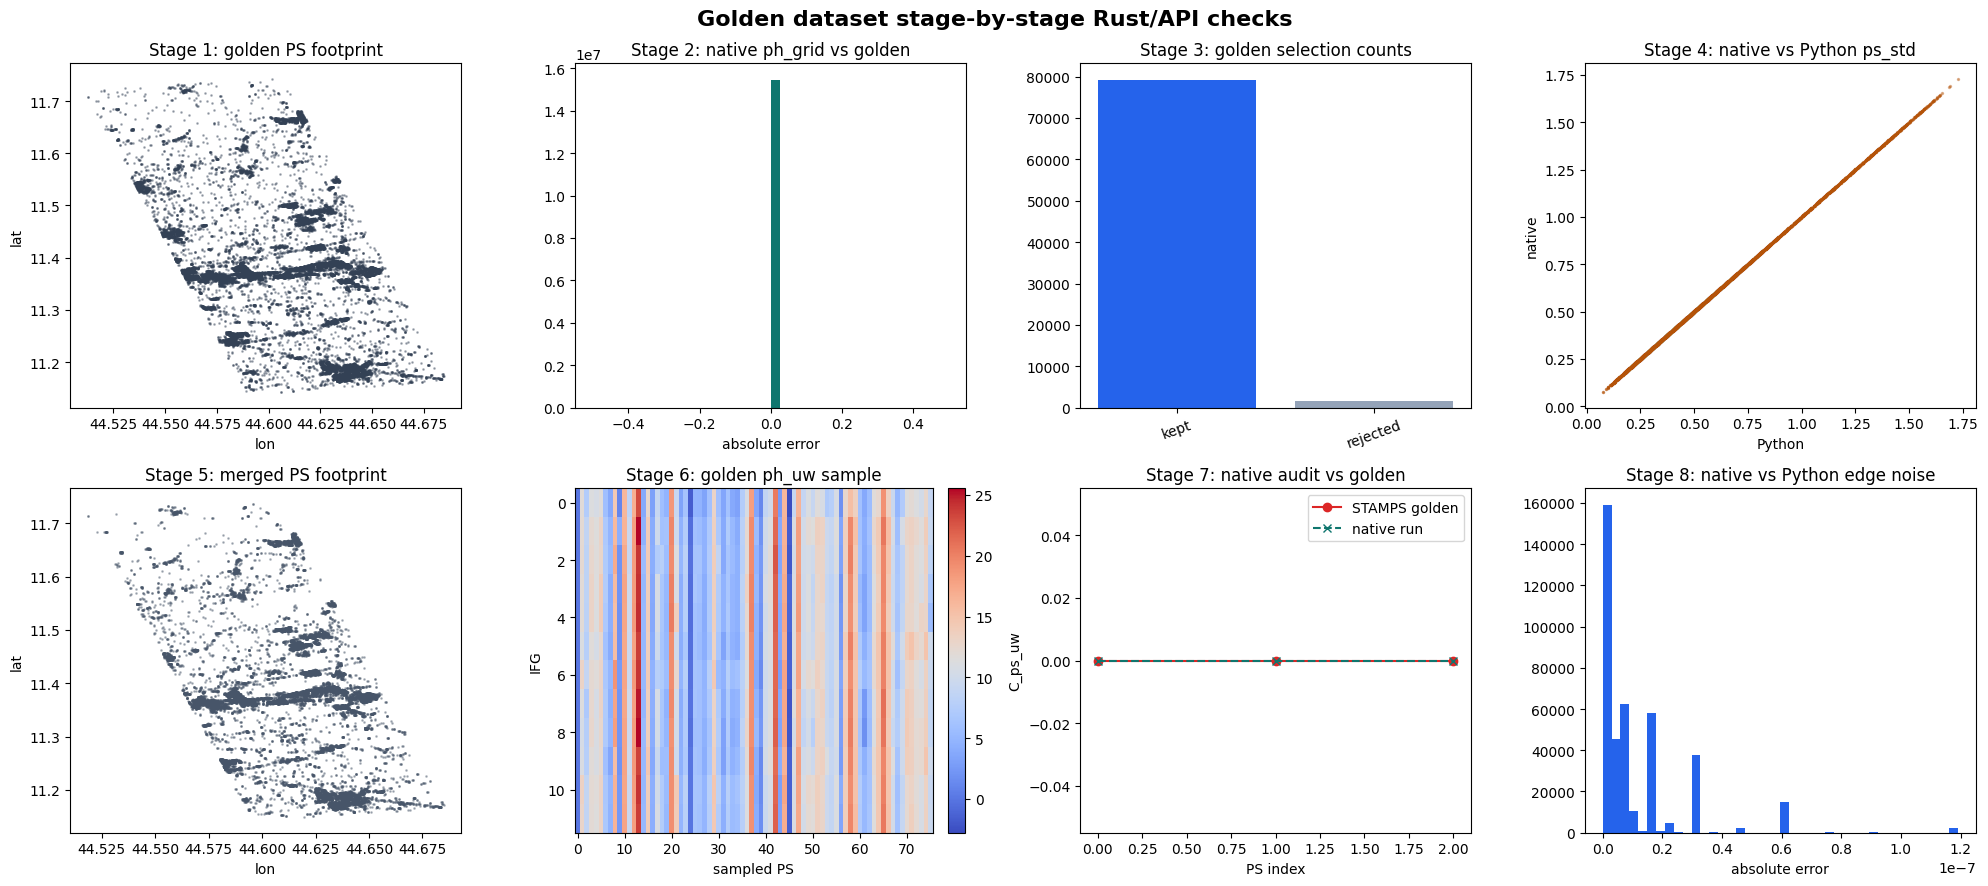

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Golden dataset stage-by-stage Rust/API checks', fontsize=16, fontweight='bold')

pts = golden_plot_payload['stage1_lonlat']
axes[0, 0].scatter(pts[:, 1], pts[:, 0], s=1, alpha=0.35, color='#334155')
axes[0, 0].set_title('Stage 1: golden PS footprint')
axes[0, 0].set_xlabel('lon')
axes[0, 0].set_ylabel('lat')

stage2_diff = golden_plot_payload['stage2_diff']
axes[0, 1].hist(stage2_diff[stage2_diff <= np.nanpercentile(stage2_diff, 99.9)], bins=40, color='#0f766e')
axes[0, 1].set_title('Stage 2: native ph_grid vs golden')
axes[0, 1].set_xlabel('absolute error')

counts = golden_plot_payload['stage3_counts']
axes[0, 2].bar(list(counts), list(counts.values()), color=['#2563eb', '#94a3b8'])
axes[0, 2].set_title('Stage 3: golden selection counts')
axes[0, 2].tick_params(axis='x', rotation=20)

axes[0, 3].scatter(golden_plot_payload['stage4_py'], golden_plot_payload['stage4_native'], s=2, alpha=0.4, color='#b45309')
axes[0, 3].set_title('Stage 4: native vs Python ps_std')
axes[0, 3].set_xlabel('Python')
axes[0, 3].set_ylabel('native')

pts = golden_plot_payload['stage5_lonlat']
axes[1, 0].scatter(pts[:, 1], pts[:, 0], s=1, alpha=0.35, color='#475569')
axes[1, 0].set_title('Stage 5: merged PS footprint')
axes[1, 0].set_xlabel('lon')
axes[1, 0].set_ylabel('lat')

im = axes[1, 1].imshow(golden_plot_payload['stage6_ph_uw'], aspect='auto', cmap='coolwarm')
axes[1, 1].set_title('Stage 6: golden ph_uw sample')
axes[1, 1].set_xlabel('sampled PS')
axes[1, 1].set_ylabel('IFG')
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

if 'stage7_run' in golden_plot_payload:
    x = np.arange(golden_plot_payload['stage7_run'].size)
    axes[1, 2].plot(x, golden_plot_payload['stage7_golden'], marker='o', label='STAMPS golden', color='#dc2626')
    axes[1, 2].plot(x, golden_plot_payload['stage7_run'], marker='x', linestyle='--', label='native run', color='#0f766e')
    axes[1, 2].legend()
else:
    axes[1, 2].text(0.5, 0.5, 'audit artifact missing', ha='center', va='center')
axes[1, 2].set_title('Stage 7: native audit vs golden')
axes[1, 2].set_xlabel('PS index')
axes[1, 2].set_ylabel('C_ps_uw')

stage8_diff = golden_plot_payload['stage8_diff']
axes[1, 3].hist(stage8_diff[stage8_diff <= np.nanpercentile(stage8_diff, 99.9)], bins=40, color='#2563eb')
axes[1, 3].set_title('Stage 8: native vs Python edge noise')
axes[1, 3].set_xlabel('absolute error')

plt.tight_layout()
plt.show()


## 6. Kernel microbenchmarks: parity first, speed second

The next cell builds deterministic synthetic inputs for every Rust-relevant kernel. Python is always timed first and used as the numerical reference.

`status = measured` means the modality completed. `parity_ok` must be true before a speedup is meaningful. CUDA rows are shown where available, but only Rust/native rows count as Rust speed claims.


In [9]:
BenchmarkFn = Callable[[], Any]


def call(fn: Callable[..., Any], /, *args: Any, **kwargs: Any) -> BenchmarkFn:
    return lambda fn=fn, args=args, kwargs=kwargs: fn(*args, **kwargs)


def timed(fn: BenchmarkFn, repeats: int) -> tuple[list[float], Any]:
    fn()
    runs: list[float] = []
    output: Any = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        output = fn()
        runs.append(time.perf_counter() - t0)
    return runs, output


def output_items(value: Any) -> dict[str, np.ndarray]:
    if isinstance(value, dict):
        return {str(key): np.asarray(item) for key, item in value.items()}
    if isinstance(value, tuple):
        return {f'out_{idx}': np.asarray(item) for idx, item in enumerate(value)}
    return {'out': np.asarray(value)}


def max_abs_array(left: np.ndarray, right: np.ndarray) -> float:
    left_arr = np.asarray(left)
    right_arr = np.asarray(right)
    if left_arr.shape != right_arr.shape:
        return float('inf')
    if np.array_equal(left_arr, right_arr, equal_nan=True):
        return 0.0
    finite = np.isfinite(left_arr) & np.isfinite(right_arr)
    if not np.array_equal(left_arr[~finite], right_arr[~finite], equal_nan=True):
        return float('inf')
    return float(np.max(np.abs(left_arr[finite] - right_arr[finite]))) if np.any(finite) else 0.0


def max_abs_output(left: Any, right: Any) -> float:
    left_items = output_items(left)
    right_items = output_items(right)
    if set(left_items) != set(right_items):
        return float('inf')
    return max(max_abs_array(left_items[key], right_items[key]) for key in sorted(left_items))


def native_topofit_generic(cpxphase: np.ndarray, bperp: np.ndarray, n_trial_wraps: float, threads: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if native_mod is None:
        raise BackendUnavailableError('compiled Rust/native module is not importable')
    result = native_mod.ps_topofit_batch_generic(np.ascontiguousarray(cpxphase, dtype=np.complex128), np.ascontiguousarray(bperp, dtype=np.float64), float(n_trial_wraps), int(threads))
    return tuple(np.asarray(item) for item in result)


def native_topofit_row(cpxphase: np.ndarray, bperp_vec: np.ndarray, n_trial_wraps: float, threads: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if native_mod is None:
        raise BackendUnavailableError('compiled Rust/native module is not importable')
    result = native_mod.ps_topofit_batch_row_invariant(np.ascontiguousarray(cpxphase, dtype=np.complex128), np.ascontiguousarray(bperp_vec, dtype=np.float64), float(n_trial_wraps), int(threads))
    return tuple(np.asarray(item) for item in result)


def native_topofit_row_coh(cpxphase: np.ndarray, bperp_vec: np.ndarray, n_trial_wraps: float, threads: int) -> np.ndarray:
    if native_mod is None:
        raise BackendUnavailableError('compiled Rust/native module is not importable')
    return np.asarray(native_mod.ps_topofit_coh_row_invariant(np.ascontiguousarray(cpxphase, dtype=np.complex128), np.ascontiguousarray(bperp_vec, dtype=np.float64), float(n_trial_wraps), int(threads)), dtype=np.float64)


def benchmark_specs(native_threads: int) -> dict[str, dict[str, Any]]:
    specs: dict[str, dict[str, Any]] = {}

    rng = np.random.default_rng(101)
    nps, nifg, ni, nj = 100000, 24, 500, 20
    ph_weight = np.exp(1j * rng.normal(size=(nps, nifg))).astype(np.complex64)
    grid_lin = rng.integers(0, ni * nj, size=nps, dtype=np.int64)
    specs['stage2_grid_accumulate'] = {'stage': '2', 'tolerance': 1e-6, 'rust_source': 'native', 'fixture': f'{nps:,} points x {nifg} interferograms', 'calls': {'python': call(run_stage2_grid_accumulate_kernel, ph_weight, grid_lin, ni, nj, backend='python'), 'native': call(run_stage2_grid_accumulate_kernel, ph_weight, grid_lin, ni, nj, backend='native', threads=native_threads)}}

    rng = np.random.default_rng(102)
    values = rng.normal(size=2000000).astype(np.float64)
    centers = np.linspace(-5.0, 5.0, 401, dtype=np.float64)
    specs['stage2_histogram'] = {'stage': '2', 'tolerance': 0.0, 'rust_source': 'native', 'fixture': f'{values.size:,} samples x {centers.size} centers', 'calls': {'python': call(run_stage2_histogram_kernel, values, centers, backend='python'), 'native': call(run_stage2_histogram_kernel, values, centers, backend='native')}}

    rng = np.random.default_rng(103)
    nps, nifg = 3000, 28
    cpx = np.exp(1j * rng.normal(size=(nps, nifg))).astype(np.complex128)
    bperp = rng.normal(size=(nps, nifg)).astype(np.float64)
    specs['stage2_topofit'] = {'stage': '2', 'tolerance': 1e-9, 'rust_source': 'rust_export', 'fixture': f'{nps:,} points x {nifg} interferograms', 'calls': {'python': call(run_stage2_topofit_kernel, cpx, bperp, 1.5, backend='python'), 'native': call(run_stage2_topofit_kernel, cpx, bperp, 1.5, backend='native', threads=native_threads), 'rust_export': call(native_topofit_generic, cpx, bperp, 1.5, native_threads)}}

    rng = np.random.default_rng(99)
    nps, nifg = 10000, 28
    cpx = np.exp(1j * rng.normal(size=(nps, nifg))).astype(np.complex128)
    bvec = np.linspace(-120.0, 120.0, nifg, dtype=np.float64)
    bmat = np.broadcast_to(bvec, (nps, nifg)).copy()
    specs['stage2_topofit_row_invariant'] = {'stage': '2', 'tolerance': 1e-9, 'rust_source': 'rust_export', 'fixture': f'{nps:,} points x {nifg} row-invariant baselines', 'calls': {'python': call(run_stage2_topofit_row_invariant_kernel, cpx, bmat, 1.5, backend='python'), 'native': call(run_stage2_topofit_row_invariant_kernel, cpx, bvec, 1.5, backend='native', threads=native_threads), 'rust_export': call(native_topofit_row, cpx, bvec, 1.5, native_threads)}}

    rng = np.random.default_rng(104)
    nps, nifg = 20000, 80
    cpx = np.exp(1j * rng.normal(size=(nps, nifg))).astype(np.complex128)
    bvec = np.linspace(-120.0, 120.0, nifg, dtype=np.float64)
    bmat = np.broadcast_to(bvec, (nps, nifg)).copy()
    specs['stage2_topofit_coh_row_invariant'] = {'stage': '2', 'tolerance': 1e-9, 'rust_source': 'rust_export', 'fixture': f'{nps:,} points x {nifg} coherence samples', 'calls': {'python': call(run_stage2_topofit_coh_row_invariant_kernel, cpx, bmat, 1.5, backend='python'), 'native': call(run_stage2_topofit_coh_row_invariant_kernel, cpx, bvec, 1.5, backend='native', threads=native_threads), 'rust_export': call(native_topofit_row_coh, cpx, bvec, 1.5, native_threads)}}

    rng = np.random.default_rng(321)
    nps, nifg, nedges = 30000, 32, 60000
    ph = np.exp(1j * rng.normal(size=(nps, nifg))).astype(np.complex128)
    node_a = rng.integers(0, nps, size=nedges, dtype=np.int64)
    node_b = rng.integers(0, nps, size=nedges, dtype=np.int64)
    bperp = np.linspace(-80.0, 120.0, nifg, dtype=np.float64)
    day = np.linspace(0.0, 365.0, nifg, dtype=np.float64)
    specs['stage4_edge_stats'] = {'stage': '4', 'tolerance': 1e-10, 'rust_source': 'native', 'fixture': f'{nps:,} points x {nedges:,} edges', 'calls': {'python': call(run_stage4_edge_stats_kernel, ph, node_a, node_b, bperp, day, 360.0, False, backend='python'), 'native': call(run_stage4_edge_stats_kernel, ph, node_a, node_b, bperp, day, 360.0, False, backend='native', threads=native_threads)}}

    rng = np.random.default_rng(322)
    nps, nifg = 30000, 36
    ph_proc = rng.normal(size=(nps, nifg)).astype(np.float64)
    ph_mean_v = rng.normal(size=(nps, nifg)).astype(np.float64)
    bperp_mat = rng.normal(size=(nps, nifg)).astype(np.float64)
    ix = np.arange(nifg, dtype=np.int64)
    day = np.linspace(0.0, 365.0, nifg, dtype=np.float64)
    ifg_std = np.full(nifg, 10.0, dtype=np.float64)
    specs['stage7_scla'] = {'stage': '7', 'tolerance': 1e-4, 'rust_source': 'native', 'fixture': f'{nps:,} points x {nifg} acquisitions', 'calls': {'python': call(run_stage7_scla_kernel, ph_proc, ph_mean_v, bperp_mat, ix, ix, day, 1, ifg_std, backend='python'), 'native': call(run_stage7_scla_kernel, ph_proc, ph_mean_v, bperp_mat, ix, ix, day, 1, ifg_std, backend='native'), 'cuda': call(run_stage7_scla_kernel, ph_proc, ph_mean_v, bperp_mat, ix, ix, day, 1, ifg_std, backend='cuda')}}

    rng = np.random.default_rng(323)
    nps, nifg, nedges = 50000, 36, 120000
    uw_ph = np.exp(1j * rng.normal(size=(nps, nifg))).astype(np.complex64)
    node_a = rng.integers(0, nps, size=nedges, dtype=np.int64)
    node_b = rng.integers(0, nps, size=nedges, dtype=np.int64)
    specs['stage8_edge_noise'] = {'stage': '8', 'tolerance': 1e-5, 'rust_source': 'native', 'fixture': f'{nps:,} points x {nedges:,} edges', 'calls': {'python': call(run_stage8_edge_noise_kernel, uw_ph, node_a, node_b, backend='python'), 'native': call(run_stage8_edge_noise_kernel, uw_ph, node_a, node_b, backend='native'), 'cuda': call(run_stage8_edge_noise_kernel, uw_ph, node_a, node_b, backend='cuda')}}

    return specs


repeats = int(os.environ.get('PYSTAMPS_NOTEBOOK_BENCH_REPEATS', '1'))
native_threads = int(os.environ.get('PYSTAMPS_NOTEBOOK_NATIVE_THREADS', '8'))
specs = benchmark_specs(native_threads)
bench_rows: list[dict[str, Any]] = []

for kernel, spec in specs.items():
    calls = spec['calls']
    available = list(backend_matrix['kernels'][kernel].get('available_backends', []))
    requested = [backend for backend in available if backend in calls]
    if 'rust_export' in calls:
        requested.append('rust_export')

    try:
        python_runs, python_output = timed(calls['python'], repeats)
        python_mean = statistics.mean(python_runs)
        bench_rows.append({'stage': spec['stage'], 'kernel': kernel, 'fixture': spec['fixture'], 'modality': 'python', 'call_path': 'public_api', 'status': 'measured', 'mean_sec': python_mean, 'speedup_vs_python': 1.0, 'max_abs': 0.0, 'tolerance': spec['tolerance'], 'parity_ok': True, 'rust_speed_claim': False, 'runs_sec': ', '.join(f'{value:.4f}' for value in python_runs), 'note': 'reference baseline'})
    except Exception as exc:
        bench_rows.append({'stage': spec['stage'], 'kernel': kernel, 'fixture': spec['fixture'], 'modality': 'python', 'call_path': 'public_api', 'status': 'failed', 'mean_sec': np.nan, 'speedup_vs_python': np.nan, 'max_abs': np.nan, 'tolerance': spec['tolerance'], 'parity_ok': False, 'rust_speed_claim': False, 'runs_sec': '', 'note': f'{type(exc).__name__}: {exc}'})
        continue

    for modality in requested:
        if modality == 'python':
            continue
        call_path = 'compiled_rust_export' if modality == 'rust_export' else 'public_api'
        try:
            runs, output = timed(calls[modality], repeats)
            mean_sec = statistics.mean(runs)
            max_abs = max_abs_output(python_output, output)
            parity_ok = bool(max_abs <= float(spec['tolerance']))
            speedup = python_mean / mean_sec if mean_sec > 0 else float('inf')
            rust_speed_claim = bool(modality == spec['rust_source'] and parity_ok and speedup > 1.0)
            if modality == 'native' and kernel in TOPIFIT_EXPORT_KERNELS:
                note = 'public native request is parity-guarded; Rust export speed is measured separately'
            elif modality == 'cuda':
                note = 'CUDA modality; not counted as Rust speed claim'
            elif modality == 'rust_export':
                note = 'direct compiled Rust export measured against Python reference'
            else:
                note = 'user-switchable accelerated backend'
            bench_rows.append({'stage': spec['stage'], 'kernel': kernel, 'fixture': spec['fixture'], 'modality': modality, 'call_path': call_path, 'status': 'measured', 'mean_sec': mean_sec, 'speedup_vs_python': speedup, 'max_abs': max_abs, 'tolerance': spec['tolerance'], 'parity_ok': parity_ok, 'rust_speed_claim': rust_speed_claim, 'runs_sec': ', '.join(f'{value:.4f}' for value in runs), 'note': note})
        except Exception as exc:
            bench_rows.append({'stage': spec['stage'], 'kernel': kernel, 'fixture': spec['fixture'], 'modality': modality, 'call_path': call_path, 'status': 'skipped', 'mean_sec': np.nan, 'speedup_vs_python': np.nan, 'max_abs': np.nan, 'tolerance': spec['tolerance'], 'parity_ok': False, 'rust_speed_claim': False, 'runs_sec': '', 'note': f'{type(exc).__name__}: {exc}'})

    for modality in [backend for backend in available if backend not in calls]:
        bench_rows.append({'stage': spec['stage'], 'kernel': kernel, 'fixture': spec['fixture'], 'modality': modality, 'call_path': 'public_api', 'status': 'skipped', 'mean_sec': np.nan, 'speedup_vs_python': np.nan, 'max_abs': np.nan, 'tolerance': spec['tolerance'], 'parity_ok': False, 'rust_speed_claim': False, 'runs_sec': '', 'note': 'available in matrix but no didactic fixture is defined in this notebook'})

bench_df = pd.DataFrame(bench_rows)
bench_display = bench_df.copy()
for column in ['mean_sec', 'speedup_vs_python']:
    bench_display[column] = bench_display[column].map(lambda value: round(float(value), 4) if pd.notna(value) else value)
for column in ['max_abs', 'tolerance']:
    bench_display[column] = bench_display[column].map(lambda value: f'{float(value):.2e}' if pd.notna(value) else value)

display(bench_display[['stage', 'kernel', 'modality', 'call_path', 'status', 'mean_sec', 'speedup_vs_python', 'max_abs', 'tolerance', 'parity_ok', 'rust_speed_claim', 'note']])


,stage,kernel,modality,call_path,status,mean_sec,speedup_vs_python,max_abs,tolerance,parity_ok,rust_speed_claim,note
0,2,stage2_grid_accumulate,python,public_api,measured,0.0204,1.0000,0.00e+00,1.00e-06,True,False,reference baseline
1,2,stage2_grid_accumulate,native,public_api,measured,0.0046,4.4088,0.00e+00,1.00e-06,True,True,user-switchable accelerated backend
2,2,stage2_histogram,python,public_api,measured,0.1385,1.0000,0.00e+00,0.00e+00,True,False,reference baseline
3,2,stage2_histogram,native,public_api,measured,0.1047,1.3233,0.00e+00,0.00e+00,True,True,user-switchable accelerated backend
4,2,stage2_topofit,python,public_api,measured,0.4522,1.0000,0.00e+00,1.00e-09,True,False,reference baseline
5,2,stage2_topofit,native,public_api,measured,0.4456,1.0148,0.00e+00,1.00e-09,True,False,public native request is parity-guarded; Rust ...
6,2,stage2_topofit,rust_export,compiled_rust_export,measured,0.0096,47.3149,5.55e-16,1.00e-09,True,True,direct compiled Rust export measured against P...
7,2,stage2_topofit_row_invariant,python,public_api,measured,1.4728,1.0000,0.00e+00,1.00e-09,True,False,reference baseline
8,2,stage2_topofit_row_invariant,native,public_api,measured,1.4807,0.9947,0.00e+00,1.00e-09,True,False,public native request is parity-guarded; Rust ...
9,2,stage2_topofit_row_invariant,rust_export,compiled_rust_export,measured,0.0130,113.5418,5.55e-16,1.00e-09,True,True,direct compiled Rust export measured against P...


## 7. Rust speed evidence by kernel

This table selects the Rust/native evidence row for each Rust-relevant kernel.

- `public_api` means users get this path by selecting `backend="native"` or a native config override.
- `compiled_rust_export` means the Rust export is measured directly because the high-level API is currently parity-guarded for that topofit path.


In [10]:
rust_claim_rows = []
for kernel in sorted(RUST_SPEED_KERNELS):
    candidates = bench_df[(bench_df['kernel'] == kernel) & (bench_df['rust_speed_claim'])].copy()
    if candidates.empty:
        rust_claim_rows.append({'stage': stage_from_kernel(kernel), 'kernel': kernel, 'speed_evidence_source': '<missing>', 'status': 'missing', 'speedup_vs_python': np.nan, 'max_abs': np.nan, 'tolerance': np.nan, 'parity_ok': False, 'rust_speed_claim': False})
        continue
    best = candidates.sort_values('speedup_vs_python', ascending=False).iloc[0]
    rust_claim_rows.append({'stage': best['stage'], 'kernel': kernel, 'speed_evidence_source': best['call_path'], 'status': best['status'], 'speedup_vs_python': best['speedup_vs_python'], 'max_abs': best['max_abs'], 'tolerance': best['tolerance'], 'parity_ok': bool(best['parity_ok']), 'rust_speed_claim': bool(best['rust_speed_claim'])})

rust_claim_df = pd.DataFrame(rust_claim_rows)
rust_claim_display = rust_claim_df.copy()
rust_claim_display['speedup_vs_python'] = rust_claim_display['speedup_vs_python'].map(lambda value: round(float(value), 3) if pd.notna(value) else value)
for column in ['max_abs', 'tolerance']:
    rust_claim_display[column] = rust_claim_display[column].map(lambda value: f'{float(value):.2e}' if pd.notna(value) else value)
display(rust_claim_display)

display(pd.DataFrame([
    {'check': 'all Rust-relevant kernels have a measured speed claim', 'result': bool(rust_claim_df['rust_speed_claim'].all())},
    {'check': 'all Rust speed rows pass parity', 'result': bool(rust_claim_df['parity_ok'].all())},
    {'check': 'minimum Rust speedup versus Python', 'result': round(float(rust_claim_df['speedup_vs_python'].min()), 3)},
    {'check': 'benchmark repeats per modality', 'result': repeats},
    {'check': 'native thread request', 'result': native_threads},
]))


,stage,kernel,speed_evidence_source,status,speedup_vs_python,max_abs,tolerance,parity_ok,rust_speed_claim
0,2,stage2_grid_accumulate,public_api,measured,4.409,0.00e+00,1.00e-06,True,True
1,2,stage2_histogram,public_api,measured,1.323,0.00e+00,0.00e+00,True,True
2,2,stage2_topofit,compiled_rust_export,measured,47.315,5.55e-16,1.00e-09,True,True
3,2,stage2_topofit_coh_row_invariant,compiled_rust_export,measured,4.008,7.77e-16,1.00e-09,True,True
4,2,stage2_topofit_row_invariant,compiled_rust_export,measured,113.542,5.55e-16,1.00e-09,True,True
5,4,stage4_edge_stats,public_api,measured,4.831,2.22e-15,1.00e-10,True,True
6,7,stage7_scla,public_api,measured,5.027,3.05e-05,1.00e-04,True,True
7,8,stage8_edge_noise,public_api,measured,2.586,4.77e-07,1.00e-05,True,True


,check,result
0,all Rust-relevant kernels have a measured spee...,True
1,all Rust speed rows pass parity,True
2,minimum Rust speedup versus Python,1.323
3,benchmark repeats per modality,1
4,native thread request,8


## 8. Plots for all measured modalities

Notebook `02` uses plots to make stage behavior visible. Here the behavior is backend modality, so the plots show runtime, Rust speedup, parity error, and coverage/status.


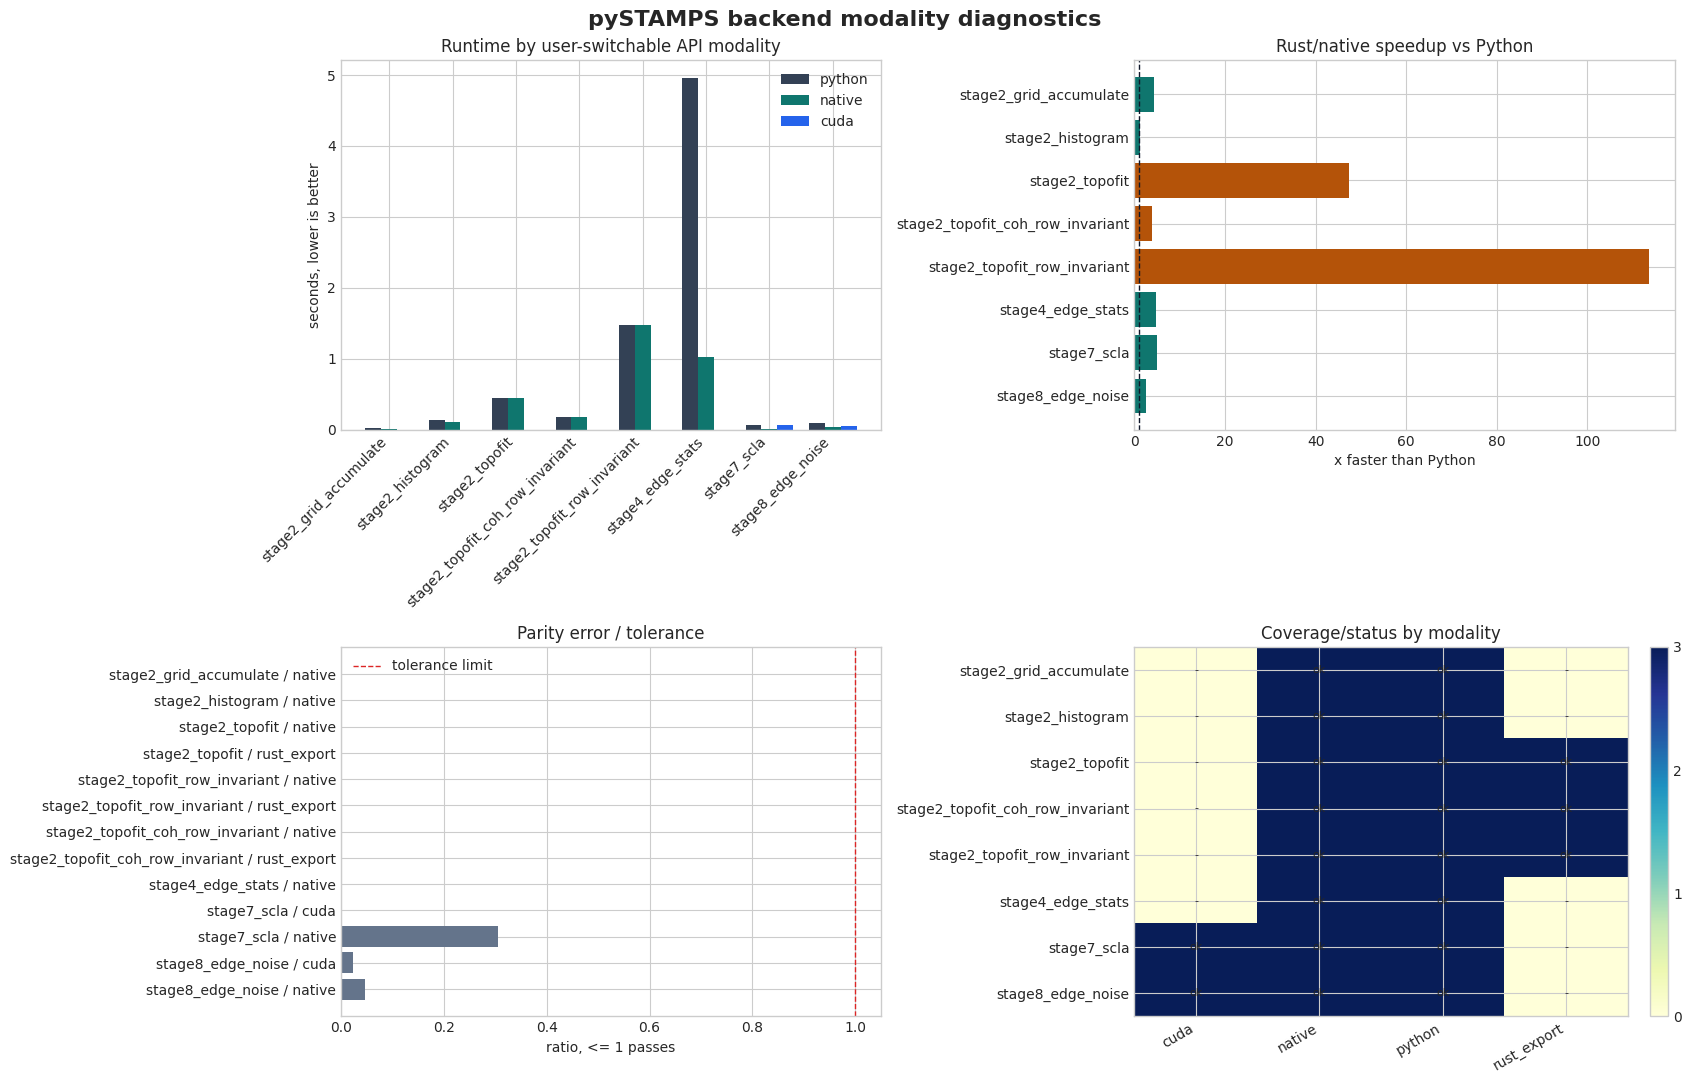

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'python': '#334155', 'native': '#0f766e', 'rust_export': '#b45309', 'cuda': '#2563eb'}
measured = bench_df[bench_df['status'] == 'measured'].copy()
api_measured = measured[measured['modality'].isin(['python', 'native', 'cuda'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle('pySTAMPS backend modality diagnostics', fontsize=16, fontweight='bold')

runtime_pivot = api_measured.pivot_table(index='kernel', columns='modality', values='mean_sec', aggfunc='min').reindex(sorted(api_measured['kernel'].unique()))
x = np.arange(len(runtime_pivot.index))
width = 0.25
for offset, modality in enumerate(['python', 'native', 'cuda']):
    if modality in runtime_pivot:
        axes[0, 0].bar(x + (offset - 1) * width, runtime_pivot[modality], width=width, label=modality, color=COLORS.get(modality))
axes[0, 0].set_title('Runtime by user-switchable API modality')
axes[0, 0].set_ylabel('seconds, lower is better')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(runtime_pivot.index, rotation=45, ha='right')
axes[0, 0].legend()

rust_plot = rust_claim_df.sort_values(['stage', 'kernel']).copy()
bar_colors = ['#b45309' if source == 'compiled_rust_export' else '#0f766e' for source in rust_plot['speed_evidence_source']]
axes[0, 1].barh(rust_plot['kernel'], rust_plot['speedup_vs_python'], color=bar_colors)
axes[0, 1].axvline(1.0, color='#0f172a', linestyle='--', linewidth=1)
axes[0, 1].set_title('Rust/native speedup vs Python')
axes[0, 1].set_xlabel('x faster than Python')
axes[0, 1].invert_yaxis()

parity_rows = measured[measured['modality'] != 'python'].copy()
parity_rows['error_ratio'] = np.where(parity_rows['tolerance'].astype(float) > 0, parity_rows['max_abs'].astype(float) / parity_rows['tolerance'].astype(float), np.where(parity_rows['max_abs'].astype(float) == 0, 0.0, np.inf))
parity_rows['label'] = parity_rows['kernel'] + ' / ' + parity_rows['modality']
finite_ratio = parity_rows['error_ratio'].replace([np.inf, -np.inf], np.nan).fillna(10.0)
axes[1, 0].barh(parity_rows['label'], finite_ratio, color='#64748b')
axes[1, 0].axvline(1.0, color='#dc2626', linestyle='--', linewidth=1, label='tolerance limit')
axes[1, 0].set_title('Parity error / tolerance')
axes[1, 0].set_xlabel('ratio, <= 1 passes')
axes[1, 0].invert_yaxis()
axes[1, 0].legend()

status_order = {'missing': 0, 'skipped': 1, 'failed': 2, 'measured': 3}
coverage = bench_df.copy()
coverage['status_code'] = coverage['status'].map(status_order).fillna(0)
coverage_pivot = coverage.pivot_table(index='kernel', columns='modality', values='status_code', aggfunc='max').fillna(0).reindex(sorted(coverage['kernel'].unique()))
image = axes[1, 1].imshow(coverage_pivot.to_numpy(), aspect='auto', cmap='YlGnBu', vmin=0, vmax=3)
axes[1, 1].set_title('Coverage/status by modality')
axes[1, 1].set_xticks(np.arange(len(coverage_pivot.columns)))
axes[1, 1].set_xticklabels(coverage_pivot.columns, rotation=30, ha='right')
axes[1, 1].set_yticks(np.arange(len(coverage_pivot.index)))
axes[1, 1].set_yticklabels(coverage_pivot.index)
for row in range(coverage_pivot.shape[0]):
    for col in range(coverage_pivot.shape[1]):
        label = {0: '-', 1: 'skip', 2: 'fail', 3: 'ok'}[int(coverage_pivot.iloc[row, col])]
        axes[1, 1].text(col, row, label, ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axes[1, 1], ticks=[0, 1, 2, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 9. StaMPS golden dataset parity

The benchmark above proves kernel-level parity against Python. StaMPS parity is checked by the audit workflow against golden data.

This notebook reads the latest focused small-baseline audit artifact if it exists. It does **not** claim that a fresh full audit was run here. Use `make audit` for the maintained full parity gate.


In [12]:
if AUDIT_JSON.exists():
    audit_payload = json.loads(AUDIT_JSON.read_text(encoding='utf-8'))
    display(pd.DataFrame([
        {'field': 'artifact', 'value': relpath(AUDIT_JSON)},
        {'field': 'generated_at_utc', 'value': audit_payload.get('generated_at_utc', '<missing>')},
        {'field': 'ok', 'value': audit_payload.get('ok')},
        {'field': 'completed', 'value': audit_payload.get('completed')},
        {'field': 'interrupted', 'value': audit_payload.get('interrupted')},
        {'field': 'failed_workflows', 'value': audit_payload.get('failed_workflows')},
        {'field': 'audit_count', 'value': len(audit_payload.get('audits', []))},
    ]))
    audit_rows = []
    for item in audit_payload.get('audits', []):
        audit_rows.append({'workflow': item.get('workflow'), 'dataset': relpath(item.get('dataset', '')), 'ok': item.get('ok'), 'checked': item.get('checked'), 'failed': item.get('failed'), 'status': item.get('status')})
    if audit_rows:
        display(pd.DataFrame(audit_rows))
else:
    audit_payload = {'ok': False, 'completed': False, 'interrupted': False, 'audits': []}
    display(pd.DataFrame([{'artifact': relpath(AUDIT_JSON), 'status': 'missing; run make audit or the focused validation notebook'}]))


,field,value
0,artifact,inputs_and_outputs/validation_runs/latest_smal...
1,generated_at_utc,2026-04-22T15:21:36Z
2,ok,True
3,completed,True
4,interrupted,False
5,failed_workflows,[]
6,audit_count,2


,workflow,dataset,ok,checked,failed,status
0,InSAR_dataset_small_baseline_stage7diag_audit,InSAR_dataset_small_baseline_stage7diag,True,4,0,passed
1,InSAR_dataset_small_baseline_stage7_audit,InSAR_dataset_small_baseline_stage7,True,4,0,passed


## 10. Final reading checklist

This is the compact conclusion for the notebook.


In [13]:
api_modalities_complete = True
missing_api_rows = []
for kernel, info in backend_matrix.get('kernels', {}).items():
    for modality in info.get('available_backends', []):
        match = bench_df[(bench_df['kernel'] == kernel) & (bench_df['modality'] == modality)]
        if match.empty:
            api_modalities_complete = False
            missing_api_rows.append(f'{kernel}/{modality}')

final_checks = pd.DataFrame([
    {'question': 'Can the notebook explain the public pySTAMPS API?', 'answer': True},
    {'question': 'Can users see how to switch backend modality?', 'answer': True},
    {'question': 'Does start_here show Rust API calls on golden data?', 'answer': bool((golden_stage_df['status'].isin(['pass', 'context'])).all())},
    {'question': 'Did every available API modality get a measured or skipped row?', 'answer': api_modalities_complete},
    {'question': 'Does every Rust-relevant kernel have a speed claim?', 'answer': bool(rust_claim_df['rust_speed_claim'].all())},
    {'question': 'Do all Rust speed rows pass parity?', 'answer': bool(rust_claim_df['parity_ok'].all())},
    {'question': 'Is the focused StaMPS audit artifact clean?', 'answer': bool(audit_payload.get('ok') and audit_payload.get('completed') and not audit_payload.get('interrupted'))},
    {'question': 'Did this notebook claim a fresh full manifest audit?', 'answer': False},
])
display(final_checks)

if missing_api_rows:
    display(pd.DataFrame({'missing_api_row': missing_api_rows}))

next_notebooks = (
    'Next notebooks:\n\n'
    '- `00_pystamps_beginner_walkthrough.ipynb`: gentler radar and workflow introduction.\n'
    '- `02_pystamps_stage_execution.ipynb`: full stage-by-stage execution and artifact plots.\n'
    '- `04_rust_end2end_parity_validation.ipynb`: Rust/native parity and validation evidence appendix.'
)
display(Markdown(next_notebooks))


,question,answer
0,Can the notebook explain the public pySTAMPS API?,True
1,Can users see how to switch backend modality?,True
2,Does start_here show Rust API calls on golden ...,True
3,Did every available API modality get a measure...,True
4,Does every Rust-relevant kernel have a speed c...,True
5,Do all Rust speed rows pass parity?,True
6,Is the focused StaMPS audit artifact clean?,True
7,Did this notebook claim a fresh full manifest ...,False


Next notebooks:

- `00_pystamps_beginner_walkthrough.ipynb`: gentler radar and workflow introduction.
- `02_pystamps_stage_execution.ipynb`: full stage-by-stage execution and artifact plots.
- `04_rust_end2end_parity_validation.ipynb`: Rust/native parity and validation evidence appendix.